In [ ]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import histogram

In [ ]:
df = pd.read_csv('data.csv')
df.head()

,Month,Day,Month.1,Day.1,EventID,MDSOTeamIncidentReview_AssignedTo,Month.2,Day.2,Month.3,Day.3
0,NaN,NaN,NaN,NaN,215153,17897,July,6,June,6
1,NaN,NaN,NaN,NaN,215742,33634,July,24,June,9
2,NaN,NaN,NaN,NaN,216274,17897,July,10,June,10
3,NaN,NaN,NaN,NaN,217001,17897,July,12,June,12
4,NaN,NaN,NaN,NaN,217019,17897,July,12,June,12


In [ ]:
df['EventCreatedDateStr'] = df['Month.3'] + ' ' + df['Day.3'].astype('Int64').astype(str) + ', 2026'
df['EventCreatedDate'] = pd.to_datetime(df['EventCreatedDateStr'], format='%B %d, %Y', errors='coerce')
df.drop(columns=['EventCreatedDateStr'], inplace=True)

df['ReviewStartDateStr'] = df['Month'] + ' ' + df['Day'].astype('Int64').astype(str) + ', 2026'
df['ReviewStartDate'] = pd.to_datetime(df['ReviewStartDateStr'], format='%B %d, %Y', errors='coerce')
df.drop(columns=['ReviewStartDateStr'], inplace=True)

df['ReviewEndDateStr'] = df['Month.1'] + ' ' + df['Day.1'].astype('Int64').astype(str) + ', 2026'
df['ReviewEndDate'] = pd.to_datetime(df['ReviewEndDateStr'], format='%B %d, %Y', errors='coerce')
df.drop(columns=['ReviewEndDateStr'], inplace=True)

df['ReviewDueDateStr'] = df['Month.2'] + ' ' + df['Day.2'].astype('Int64').astype(str) + ', 2026'
df['ReviewDueDate'] = pd.to_datetime(df['ReviewDueDateStr'], format='%B %d, %Y', errors='coerce')
df.drop(columns=['ReviewDueDateStr'], inplace=True)

display(df.head(100))

,Month,Day,Month.1,Day.1,EventID,MDSOTeamIncidentReview_AssignedTo,Month.2,Day.2,Month.3,Day.3,EventCreatedDate,ReviewStartDate,ReviewEndDate,ReviewDueDate
0,NaN,NaN,NaN,NaN,215153,17897,July,6,June,6,2026-06-06,NaT,NaT,2026-07-06
1,NaN,NaN,NaN,NaN,215742,33634,July,24,June,9,2026-06-09,NaT,NaT,2026-07-24
2,NaN,NaN,NaN,NaN,216274,17897,July,10,June,10,2026-06-10,NaT,NaT,2026-07-10
3,NaN,NaN,NaN,NaN,217001,17897,July,12,June,12,2026-06-12,NaT,NaT,2026-07-12
4,NaN,NaN,NaN,NaN,217019,17897,July,12,June,12,2026-06-12,NaT,NaT,2026-07-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,June,2.0,June,28.0,212730,17898,June,27,May,28,2026-05-28,2026-06-02,2026-06-28,2026-06-27
96,June,3.0,NaN,NaN,213050,17898,June,28,May,29,2026-05-29,2026-06-03,NaT,2026-06-28
97,June,3.0,NaN,NaN,213230,17898,July,27,May,29,2026-05-29,2026-06-03,NaT,2026-07-27
98,June,3.0,May,27.0,212340,36596,June,26,May,27,2026-05-27,2026-06-03,2026-05-27,2026-06-26


N incidents created: 155
N new reviews started: 125
N new reviews completed: 76
Average review duration: 1 day(s)
Average turnaround time: 4 day(s)
N reviews with turnaround <3 days: 40 (52.63%)


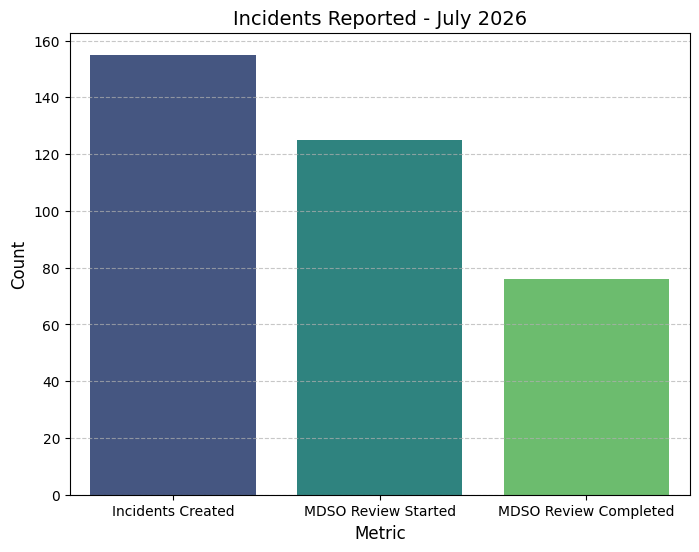

In [ ]:
# --------------------------------------
## Incidents created in July
# --------------------------------------
# Criteria:
# 'EventCreatedDate' AFTER 01/07/2026
date_beginning = datetime.datetime(2026,7,1)

df_created_post_start_of_month = df[df['EventCreatedDate'] >= date_beginning].copy()
df_created_post_start_of_month.sort_values(by='EventCreatedDate', inplace=True)
df_created_post_start_of_month['ReviewDuration'] = df_created_post_start_of_month['ReviewEndDate'] - df_created_post_start_of_month['ReviewStartDate']
df_created_post_start_of_month['ReviewTurnaroundSinceEventCreated'] = df_created_post_start_of_month['ReviewEndDate'] - df_created_post_start_of_month['EventCreatedDate']

n_incidents_created = len(df_created_post_start_of_month)
n_reviews_started = len(df_created_post_start_of_month[df_created_post_start_of_month['ReviewStartDate'].notna()])
n_reviews_ended = len(df_created_post_start_of_month[df_created_post_start_of_month['ReviewEndDate'].notna()])

average_review_duration = df_created_post_start_of_month['ReviewDuration'].mean()
average_turnaround_time = df_created_post_start_of_month['ReviewTurnaroundSinceEventCreated'].mean()
threshold = 3
n_short_turnaround = len(df_created_post_start_of_month[df_created_post_start_of_month['ReviewTurnaroundSinceEventCreated'].dt.days < threshold])
n_turnaround = len(df_created_post_start_of_month[df_created_post_start_of_month['ReviewTurnaroundSinceEventCreated'].notna()])

print(f"N incidents created: {n_incidents_created}")
print(f"N new reviews started: {n_reviews_started}")
print(f"N new reviews completed: {n_reviews_ended}")
print(f"Average review duration: {average_review_duration.days} day(s)")
print(f"Average turnaround time: {average_turnaround_time.days} day(s)")
print(f"N reviews with turnaround <{threshold} days: {n_short_turnaround} ({round((n_short_turnaround/n_turnaround)*100,2)}%)")

# Plot
data = {
    'Metric': ['Incidents Created', 'MDSO Review Started', 'MDSO Review Completed'],
    'Count': [n_incidents_created, n_reviews_started, n_reviews_ended]
}
metrics_df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Count', data=metrics_df, hue='Metric', palette='viridis', legend=False)

plt.title('Incidents Reported - July 2026', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

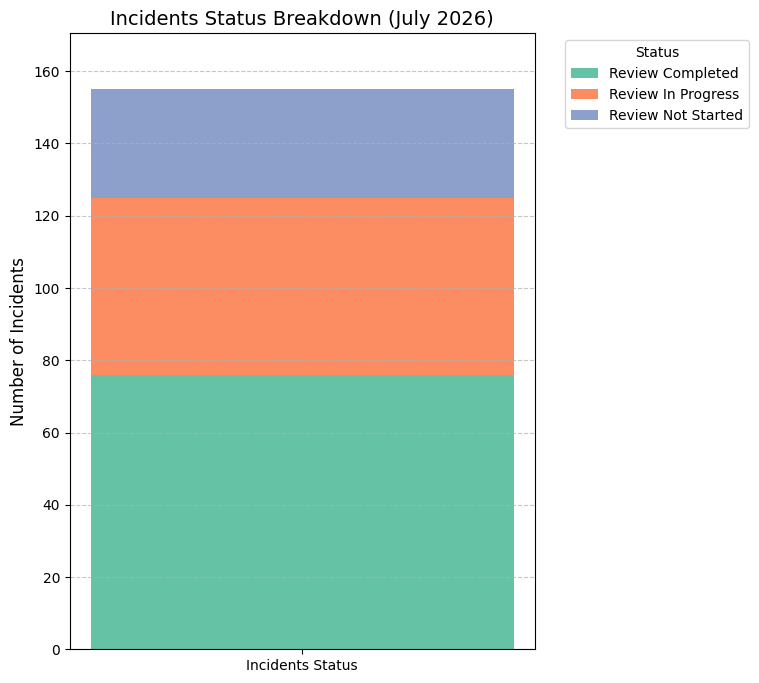

In [ ]:
# Calculate the segments for the stacked bar
completed_count = n_reviews_ended
started_not_completed_count = n_reviews_started - n_reviews_ended
created_not_started_count = n_incidents_created - n_reviews_started

# Create a list of the counts and labels for plotting
counts = [completed_count, started_not_completed_count, created_not_started_count]
labels = ['Review Completed', 'Review In Progress', 'Review Not Started']

# Define colors for the segments
colors = ['#66c2a5', '#fc8d62', '#8da0cb'] # Example colors

plt.figure(figsize=(6, 8))

# Plot the stacked bar segments
bottom = 0
for i in range(len(counts)):
    plt.bar(
        'Incidents Status',
        counts[i],
        bottom=bottom,
        label=labels[i],
        color=colors[i]
    )
    bottom += counts[i]

plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Incidents Status Breakdown (July 2026)', fontsize=14)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, n_incidents_created * 1.1) # Set y-limit to slightly above total
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# --------------------------------------
## Incidents still pending review close as of start of July
# --------------------------------------
# Criteria:
# 'EventCreatedDate' BEFORE 01/07/2026
# AND ('ReviewEndDate' AFTER 01/07/2026) OR ('ReviewEndDate' missing)
date_beginning = datetime.datetime(2026,7,1)
df_created_pre_start_of_month = df[df['EventCreatedDate'] <= date_beginning].copy()
df_created_pre_start_of_month.sort_values(by='EventCreatedDate', inplace=True)
df_created_pre_start_of_month['ReviewDuration'] = df_created_pre_start_of_month['ReviewEndDate'] - df_created_pre_start_of_month['ReviewStartDate']
df_created_pre_start_of_month['ReviewTurnaroundSinceEventCreated'] = df_created_pre_start_of_month['ReviewEndDate'] - df_created_pre_start_of_month['EventCreatedDate']
df_created_pre_start_of_month.head(100)

df_unclosed_as_of_start_of_month = df_created_pre_start_of_month[
    (df_created_pre_start_of_month["ReviewEndDate"] > date_beginning) | (df_created_pre_start_of_month["ReviewEndDate"].isna())
].copy()

df_unclosed_as_of_start_of_month.head(100)
n_unclosed_as_of_start_of_month = len(df_unclosed_as_of_start_of_month)

print(f"N incidents with review not closed as of start of month: {n_unclosed_as_of_start_of_month}")

N incidents with review not closed as of start of month: 126


/tmp/ipykernel_1251/1342989578.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_filtered, x="TurnaroundBin", palette=palette)


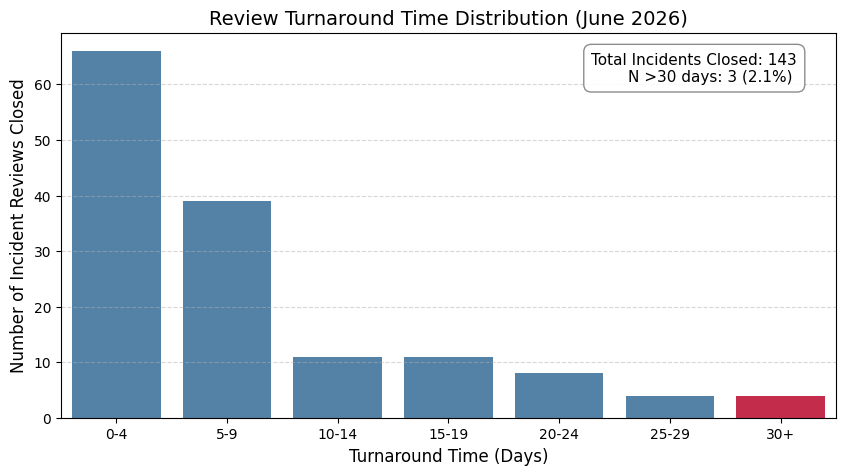

In [ ]:
# --------------------------------------
## % incidents turned around in >30 days
# --------------------------------------
# Criteria:
# Every incident CLOSED within the PREVIOUS month - this prevents any double counting?
# Eg. for July KPIs, it would be (N incidents closed in June with review >30 days)/(N incidents closed in June)

date_beginning = datetime.datetime(2026,6,1)
date_end = datetime.datetime(2026,6,30)
df_filtered = df[(df['ReviewEndDate'] >= date_beginning) & (df['ReviewEndDate'] <= date_end)].copy()
df_filtered.sort_values(by='ReviewEndDate', inplace=True)

df_filtered['ReviewDuration'] = df_filtered['ReviewEndDate'] - df_filtered['ReviewStartDate']
df_filtered['ReviewTurnaroundSinceEventCreated'] = df_filtered['ReviewEndDate'] - df_filtered['EventCreatedDate']
df_filtered.head(100)

n_long_turnaround = len(df_filtered[df_filtered['ReviewTurnaroundSinceEventCreated'].dt.days > 30])
df_filtered.head(100)

# Plot
# 1. Extract numeric days from the text column
df_filtered["TurnaroundDays"] = (
    df_filtered["ReviewTurnaroundSinceEventCreated"]
    .dt.days
)

# 2. Define custom bin ranges and labels
bins = [-1, 4, 9, 14, 19, 24, 29, np.inf]
labels = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', "30+"]

df_filtered["TurnaroundBin"] = pd.cut(df_filtered["TurnaroundDays"], bins=bins, labels=labels)

# 3. Define a palette: red for '30+' and blue/gray for the rest
palette = ["crimson" if label == "30+" else "steelblue" for label in labels]

# 4. Plot using Seaborn countplot
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_filtered, x="TurnaroundBin", palette=palette)

# 5. Add text annotation
ax.text(
    0.95,
    0.95,  # Placement: x=95%, y=95% of plot area (Top Right)
    f"Total Incidents Closed: {len(df_filtered)}\nN >30 days: {n_long_turnaround} ({round((n_long_turnaround/len(df_filtered))*100,2)}%) ",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9,
    ),
)

plt.title("Review Turnaround Time Distribution (June 2026)", fontsize=14)
plt.xlabel("Turnaround Time (Days)", fontsize=12)
plt.ylabel("Number of Incident Reviews Closed", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()